<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/11-sql-ecl-mart/sql_ecl_mart_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Kaggle 사용자명(username)을 입력하세요: KIMDAEYU
Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ··········
Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
100% 0.98M/0.98M [00:00<00:00, 118MB/s]

Archive:  default-of-credit-card-clients-dataset.zip
  inflating: UCI_Credit_Card.csv     
=== 포트폴리오 전체 비교 ===
실제 부실률                : 22.12%
로지스틱 PD           : 평균 PD 22.13% (실제 대비 1.00배), AUC 0.754
XGBoost(가중치) PD   : 평균 PD 42.06% (실제 대비 1.90배), AUC 0.776


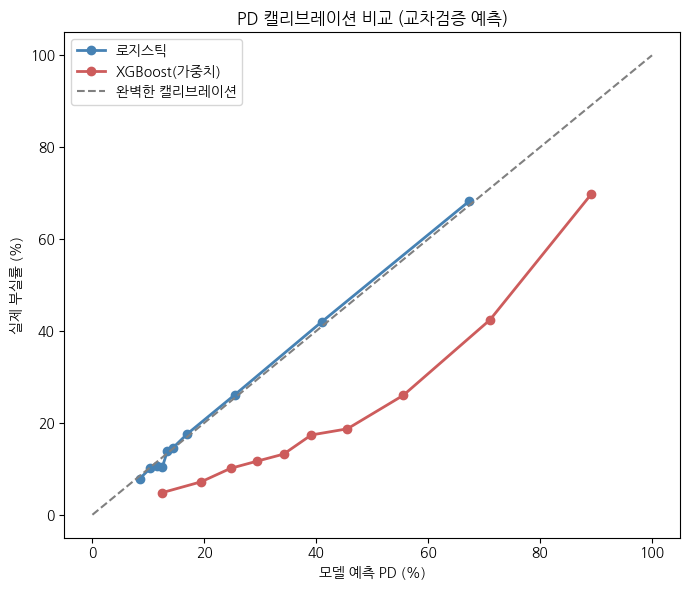

In [1]:
# ============================================================
# [Cell 1] 데이터 준비 + 전체 고객 PD 산출(교차검증) + 캘리브레이션 확인
# ============================================================

# ------------------------------------------------------------
# 0) 라이브러리 설치 및 한글 폰트 설정
# ------------------------------------------------------------
!pip install --quiet kaggle xgboost
!apt-get -qq install fonts-nanum > /dev/null 2>&1

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from getpass import getpass

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

# ------------------------------------------------------------
# 1) Kaggle 데이터 다운로드 (08번과 동일한 대만 카드사 데이터 3만 건)
# ------------------------------------------------------------
os.environ['KAGGLE_USERNAME'] = input("Kaggle 사용자명(username)을 입력하세요: ")
os.environ['KAGGLE_KEY'] = getpass("Kaggle API 키를 입력하세요 (화면에 표시되지 않습니다): ")

!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset
!unzip -o default-of-credit-card-clients-dataset.zip

df = pd.read_csv('UCI_Credit_Card.csv')
df = df.rename(columns={'default.payment.next.month': 'default'})

# ------------------------------------------------------------
# 2) 피처 엔지니어링 (08번과 동일: 연체·결제행동 지표)
# ------------------------------------------------------------
pay_cols  = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
paid_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

df['recent_delay']  = df['PAY_0'].clip(lower=0)                  # 최근월 연체 개월수
df['max_delay_6m']  = df[pay_cols].clip(lower=0).max(axis=1)     # 6개월 중 최대 연체 개월수
df['delay_freq_6m'] = (df[pay_cols] > 0).sum(axis=1)             # 6개월 중 연체 발생 횟수

bill_safe = df[bill_cols].replace(0, np.nan)                     # 청구액 0이면 비율 계산 불가 -> 결측 처리
df['avg_payment_ratio'] = (df[paid_cols].values / bill_safe.values).mean(axis=1)
df['avg_payment_ratio'] = df['avg_payment_ratio'].fillna(0).clip(0, 3)   # 결제비율(리볼빙 성향)
df['avg_utilization']   = (df[bill_cols].mean(axis=1) / df['LIMIT_BAL']).clip(0, 2)  # 한도소진율

features = ['LIMIT_BAL', 'AGE', 'recent_delay', 'max_delay_6m',
            'delay_freq_6m', 'avg_payment_ratio', 'avg_utilization']
X, y = df[features], df['default']

# ------------------------------------------------------------
# 3) 전체 고객의 PD를 교차검증(out-of-fold) 방식으로 산출
# ------------------------------------------------------------
# 충당금은 "전체 포트폴리오"에 대해 계산해야 하는데, 모델을 학습한 데이터에
# 그대로 예측하면 과적합 때문에 PD가 실제보다 좋게 나옴.
# 5-fold: 데이터를 5조각으로 나눠 "자기 자신이 학습에 안 쓰인" 모델로 예측 -> 공정한 PD
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# (A) 로지스틱 회귀: class_weight를 쓰지 않음 -> 확률이 실제 부실률에 가깝게 나오는 구조
logit_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
df['pd_logit'] = cross_val_predict(logit_pipe, X, y, cv=skf, method='predict_proba')[:, 1]

# (B) XGBoost: 08·09번과 동일하게 scale_pos_weight 적용 -> 순위는 잘 맞추지만 확률이 부풀려지는 구조
spw = (y == 0).sum() / (y == 1).sum()
xgb_weighted = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                             scale_pos_weight=spw, random_state=42, eval_metric='logloss')
df['pd_xgb_weighted'] = cross_val_predict(xgb_weighted, X, y, cv=skf, method='predict_proba')[:, 1]

# ------------------------------------------------------------
# 4) 변별력(AUC)과 캘리브레이션(평균 PD vs 실제 부실률) 비교
# ------------------------------------------------------------
from sklearn.metrics import roc_auc_score

actual_rate = y.mean()
print("=== 포트폴리오 전체 비교 ===")
print(f"실제 부실률                : {actual_rate*100:.2f}%")
for name, col in [('로지스틱 PD', 'pd_logit'), ('XGBoost(가중치) PD', 'pd_xgb_weighted')]:
    mean_pd = df[col].mean()
    print(f"{name:<18}: 평균 PD {mean_pd*100:.2f}% (실제 대비 {mean_pd/actual_rate:.2f}배), "
          f"AUC {roc_auc_score(y, df[col]):.3f}")

# ------------------------------------------------------------
# 5) 등급(Decile)별 캘리브레이션 그래프: 대각선에 붙을수록 PD를 믿을 수 있음
# ------------------------------------------------------------
def decile_calib(score_col):
    tmp = df[[score_col, 'default']].copy()
    tmp['decile'] = pd.qcut(tmp[score_col], 10, labels=False, duplicates='drop') + 1
    return tmp.groupby('decile').agg(예측PD=(score_col, 'mean'), 실제부실률=('default', 'mean'))

fig, ax = plt.subplots(figsize=(7, 6))
for name, col, color in [('로지스틱', 'pd_logit', 'steelblue'), ('XGBoost(가중치)', 'pd_xgb_weighted', 'indianred')]:
    c = decile_calib(col)
    ax.plot(c['예측PD']*100, c['실제부실률']*100, marker='o', lw=2, label=name, color=color)
ax.plot([0, 100], [0, 100], linestyle='--', color='gray', label='완벽한 캘리브레이션')
ax.set_xlabel('모델 예측 PD (%)')
ax.set_ylabel('실제 부실률 (%)')
ax.set_title('PD 캘리브레이션 비교 (교차검증 예측)')
ax.legend()
plt.tight_layout()
plt.show()

로지스틱은 평균 PD가 실제 부실률과 거의 같고, 캘리브레이션 그래프에서도 파란 선이 대각선에 붙어 있음. 충당금 계산에 PD를 그대로 쓸 수 있는 수준.
**XGBoost(가중치)**는 AUC가 0.776으로 순위 변별력은 조금 더 좋음. 하지만 평균 PD가 실제의 1.9배이고, 빨간 선이 전 구간에서 대각선 아래에 있음. 09번에서 발견한 과대예측이 교차검증으로도 다시 확인됨.
이 데이터에서는 순위를 잘 맞히는 모델과 확률값을 믿을 수 있는 모델이 다름. 이게 이번 분석의 출발점.


In [2]:
# ============================================================
# [Cell 2] SQL 마트 구축: 테이블 설계·적재 + 데이터 품질 점검
# ============================================================
import sqlite3

# ------------------------------------------------------------
# 0) 사전 확인: 1단계 셀에서 만든 PD 컬럼이 있어야 진행 가능
# ------------------------------------------------------------
assert 'pd_logit' in df.columns and 'pd_xgb_weighted' in df.columns, \
    "1단계 셀(PD 산출)을 먼저 실행해주세요."

# ------------------------------------------------------------
# 1) DB 연결 + 원본 테이블(raw_card) 적재
# ------------------------------------------------------------
# 실무에서는 원천 데이터가 이미 DB에 있으므로, 이 부분은 그 상황을 흉내 내는 '적재(ETL) 대용'
# 'default'는 SQL 예약어라 충돌하므로 default_flag로 이름을 바꿔서 적재
conn = sqlite3.connect('card_ecl_mart.db')

raw_cols = (['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE',
             'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6'] +
            [f'BILL_AMT{i}' for i in range(1, 7)] +
            [f'PAY_AMT{i}' for i in range(1, 7)] + ['default'])
raw = df[raw_cols].rename(columns={'default': 'default_flag'})
raw.to_sql('raw_card', conn, if_exists='replace', index=False)

# ------------------------------------------------------------
# 2) 마트 테이블 설계 (DDL): 하나의 큰 표를 목적별 테이블로 분리(정규화)
# ------------------------------------------------------------
# PRIMARY KEY: 고객 한 명당 한 행만 존재하도록 DB가 강제함 (중복 방지)
# month_seq: 1 = 가장 오래된 달(4월), 6 = 최근월(9월) -> 시간 순서 정렬용 번호
ddl = """
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS accounts;
DROP TABLE IF EXISTS monthly_snapshot;
DROP TABLE IF EXISTS outcomes;
DROP TABLE IF EXISTS pd_scores;

CREATE TABLE customers (
    cust_id   INTEGER PRIMARY KEY,
    sex       INTEGER,
    education INTEGER,
    marriage  INTEGER,
    age       INTEGER
);

CREATE TABLE accounts (
    cust_id   INTEGER PRIMARY KEY,
    limit_bal REAL NOT NULL
);

CREATE TABLE monthly_snapshot (
    cust_id    INTEGER NOT NULL,
    month_seq  INTEGER NOT NULL,
    pay_status INTEGER,
    bill_amt   REAL,
    pay_amt    REAL,
    PRIMARY KEY (cust_id, month_seq)
);

CREATE TABLE outcomes (
    cust_id      INTEGER PRIMARY KEY,
    default_flag INTEGER
);

CREATE TABLE pd_scores (
    cust_id         INTEGER PRIMARY KEY,
    pd_logit        REAL,
    pd_xgb_weighted REAL
);
"""
conn.executescript(ddl)

# ------------------------------------------------------------
# 3) 원본(raw_card) -> 마트 테이블로 데이터 채우기 (INSERT ... SELECT)
# ------------------------------------------------------------
# 월별 스냅샷은 가로로 펼쳐진 6개월 컬럼을 UNION ALL로 세로(고객×월)로 쌓음
# 원본 컬럼 대응: PAY_6/BILL_AMT6/PAY_AMT6 = 가장 오래된 달, PAY_0/BILL_AMT1/PAY_AMT1 = 최근월
load_sql = """
INSERT INTO customers
SELECT ID, SEX, EDUCATION, MARRIAGE, AGE FROM raw_card;

INSERT INTO accounts
SELECT ID, LIMIT_BAL FROM raw_card;

INSERT INTO outcomes
SELECT ID, default_flag FROM raw_card;

INSERT INTO monthly_snapshot
SELECT ID, 1, PAY_6, BILL_AMT6, PAY_AMT6 FROM raw_card
UNION ALL SELECT ID, 2, PAY_5, BILL_AMT5, PAY_AMT5 FROM raw_card
UNION ALL SELECT ID, 3, PAY_4, BILL_AMT4, PAY_AMT4 FROM raw_card
UNION ALL SELECT ID, 4, PAY_3, BILL_AMT3, PAY_AMT3 FROM raw_card
UNION ALL SELECT ID, 5, PAY_2, BILL_AMT2, PAY_AMT2 FROM raw_card
UNION ALL SELECT ID, 6, PAY_0, BILL_AMT1, PAY_AMT1 FROM raw_card;

CREATE INDEX idx_snapshot_month ON monthly_snapshot(month_seq);
"""
conn.executescript(load_sql)

# PD는 파이썬 모델이 산출한 결과이므로 DataFrame에서 테이블로 적재
pd_table = df[['ID', 'pd_logit', 'pd_xgb_weighted']].rename(columns={'ID': 'cust_id'})
pd_table.to_sql('pd_scores', conn, if_exists='append', index=False)
conn.commit()

def q(sql):
    """SQL을 실행하고 결과를 표(DataFrame)로 돌려주는 도우미 함수"""
    return pd.read_sql_query(sql, conn)

# ------------------------------------------------------------
# 4) 적재 검증: 테이블별 행 수 (기대값: 3만 / 3만 / 18만 / 3만 / 3만)
# ------------------------------------------------------------
print("=== 테이블별 행 수 ===")
print(q("""
SELECT 'customers' AS 테이블, COUNT(*) AS 행수 FROM customers
UNION ALL SELECT 'accounts', COUNT(*) FROM accounts
UNION ALL SELECT 'monthly_snapshot', COUNT(*) FROM monthly_snapshot
UNION ALL SELECT 'outcomes', COUNT(*) FROM outcomes
UNION ALL SELECT 'pd_scores', COUNT(*) FROM pd_scores
"""))

# ------------------------------------------------------------
# 5) 데이터 품질 점검 쿼리
# ------------------------------------------------------------
print("\n=== [점검1] 연체상태(pay_status) 코드 분포 ===")
print(q("""
SELECT pay_status, COUNT(*) AS 건수,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM monthly_snapshot), 2) AS 비중_pct
FROM monthly_snapshot
GROUP BY pay_status
ORDER BY pay_status
"""))

print("\n=== [점검2] 청구액 이상 여부 ===")
print(q("""
SELECT
    SUM(CASE WHEN s.bill_amt < 0 THEN 1 ELSE 0 END)           AS 음수_청구액_건수,
    SUM(CASE WHEN s.bill_amt > a.limit_bal THEN 1 ELSE 0 END) AS 한도초과_청구_건수,
    COUNT(*)                                                  AS 전체_건수
FROM monthly_snapshot s
JOIN accounts a ON s.cust_id = a.cust_id
"""))

print("\n=== [점검3] 정의되지 않은 코드값 (학력/혼인) ===")
print(q("""
SELECT '학력' AS 항목, education AS 코드, COUNT(*) AS 건수 FROM customers GROUP BY education
UNION ALL
SELECT '혼인', marriage, COUNT(*) FROM customers GROUP BY marriage
"""))

print("\n=== [점검4] 키 무결성 / PD 값 범위 ===")
print(q("""
SELECT
    (SELECT COUNT(*) FROM accounts a
       LEFT JOIN customers c ON a.cust_id = c.cust_id
       WHERE c.cust_id IS NULL)                                   AS 고객없는_계좌,
    (SELECT COUNT(*) FROM customers c
       LEFT JOIN pd_scores p ON c.cust_id = p.cust_id
       WHERE p.cust_id IS NULL)                                   AS PD없는_고객,
    (SELECT COUNT(*) FROM pd_scores
       WHERE pd_logit IS NULL OR pd_logit NOT BETWEEN 0 AND 1
          OR pd_xgb_weighted IS NULL OR pd_xgb_weighted NOT BETWEEN 0 AND 1) AS PD_범위이상
"""))

=== 테이블별 행 수 ===
                테이블      행수
0         customers   30000
1          accounts   30000
2  monthly_snapshot  180000
3          outcomes   30000
4         pd_scores   30000

=== [점검1] 연체상태(pay_status) 코드 분포 ===
    pay_status     건수  비중_pct
0           -2  24415   13.56
1           -1  34640   19.24
2            0  95919   53.29
3            1   3722    2.07
4            2  18964   10.54
5            3   1430    0.79
6            4    453    0.25
7            5    137    0.08
8            6     74    0.04
9            7    218    0.12
10           8     28    0.02

=== [점검2] 청구액 이상 여부 ===
   음수_청구액_건수  한도초과_청구_건수   전체_건수
0       3932        8274  180000

=== [점검3] 정의되지 않은 코드값 (학력/혼인) ===
    항목  코드     건수
0   학력   0     14
1   학력   1  10585
2   학력   2  14030
3   학력   3   4917
4   학력   4    123
5   학력   5    280
6   학력   6     51
7   혼인   0     54
8   혼인   1  13659
9   혼인   2  15964
10  혼인   3    323

=== [점검4] 키 무결성 / PD 값 범위 ===
   고객없는_계좌  PD없는_고객  PD_범위이상
0        0     

원본 한 장짜리 표(raw_card)를 고객·계좌·월별 스냅샷·성과·PD 5개 테이블로 나눠 DB에 생성. 실제 데이터 마트가 이렇게 목적별로 분리되어 있음.
PRIMARY KEY로 중복을 막고, 월별 스냅샷은 UNION ALL로 고객×월 구조(18만 행)로 쌓음. 10번 때와 달리 CREATE TABLE로 구조를 먼저 정의하고 INSERT ... SELECT로 채움.


In [3]:
# ============================================================
# [Cell 3] SQL로 Stage 판정 + EAD + ECL 계산 (뷰 설계)
# ============================================================

# 금액을 보기 좋게 표시 (과학적 표기법 e+08 방지)
pd.options.display.float_format = '{:,.2f}'.format

# ------------------------------------------------------------
# 1) ECL 파라미터 테이블 (가정값을 코드가 아니라 테이블에 둠)
# ------------------------------------------------------------
# lgd : 부도 시 손실률 (무담보 카드 가정 75%)
# ccf : 미사용 한도가 향후 실제 사용될 비율 (가정 50%)
# discount_rate : 할인율 (카드 유효이자율 대용 15%)
# -> 5단계에서 시나리오 행만 추가하면 같은 쿼리가 모든 시나리오를 자동 계산함
param_sql = """
DROP TABLE IF EXISTS ecl_params;
CREATE TABLE ecl_params (
    scenario      TEXT PRIMARY KEY,
    lgd           REAL,
    ccf           REAL,
    discount_rate REAL
);
INSERT INTO ecl_params VALUES ('base', 0.75, 0.50, 0.15);
"""
conn.executescript(param_sql)

# ------------------------------------------------------------
# 2) 고객별 Stage·사용잔액 뷰 (v_customer_stage)
# ------------------------------------------------------------
# 뷰(VIEW)는 '저장된 쿼리' -> 원본이 바뀌면 결과도 자동 갱신됨
# MAX(a, b) = 두 값 중 큰 값(스칼라), MAX(컬럼) = 집계함수 (SQLite에서 인자 수로 구분)
# 최근월 = month_seq 6
stage_sql = """
DROP VIEW IF EXISTS v_customer_stage;
CREATE VIEW v_customer_stage AS
WITH latest AS (
    SELECT cust_id,
           pay_status AS cur_status,
           MAX(bill_amt, 0) AS drawn_amt      -- 음수 청구액(과납)은 0으로 하한 처리
    FROM monthly_snapshot
    WHERE month_seq = 6
),
hist AS (
    SELECT cust_id, MAX(pay_status) AS max_status_6m   -- 6개월 중 최악의 연체상태
    FROM monthly_snapshot
    GROUP BY cust_id
)
SELECT
    a.cust_id,
    a.limit_bal,
    l.cur_status,
    h.max_status_6m,
    l.drawn_amt,
    MAX(a.limit_bal - l.drawn_amt, 0) AS undrawn_amt,   -- 한도초과면 미사용 한도 0
    CASE
        WHEN l.cur_status >= 3 THEN 3                                  -- 90일 이상 연체
        WHEN l.cur_status >= 1 OR h.max_status_6m >= 1 THEN 2          -- 30일+ 연체 또는 최근 이력
        ELSE 1
    END AS stage
FROM accounts a
JOIN latest l ON a.cust_id = l.cust_id
JOIN hist   h ON a.cust_id = h.cust_id;
"""
conn.executescript(stage_sql)

# ------------------------------------------------------------
# 3) EAD + ECL 계산 뷰 (v_ecl): 고객 x 시나리오
# ------------------------------------------------------------
# CROSS JOIN ecl_params : 파라미터 행 수만큼 고객별 결과가 복제됨 (시나리오 확장 대비)
# Stage 1 : PD x LGD x EAD / (1+r)              (12개월 ECL)
# Stage 2 : 3년 전체기간 -> 연도별 한계PD를 할인해 합산
#           t=1: PD, t=2: (1-PD)xPD, t=3: (1-PD)^2 x PD
# Stage 3 : LGD x EAD                            (이미 부도: PD 100%)
ecl_sql = """
DROP VIEW IF EXISTS v_ecl;
CREATE VIEW v_ecl AS
WITH base AS (
    SELECT
        p.scenario, s.cust_id, s.stage, s.limit_bal, s.drawn_amt,
        s.drawn_amt + CASE WHEN s.stage = 3 THEN 0.0
                           ELSE p.ccf * s.undrawn_amt END AS ead,
        p.lgd, p.discount_rate AS r,
        d.pd_logit, d.pd_xgb_weighted
    FROM v_customer_stage s
    CROSS JOIN ecl_params p
    JOIN pd_scores d ON s.cust_id = d.cust_id
)
SELECT
    scenario, cust_id, stage, limit_bal, drawn_amt, ead, pd_logit, pd_xgb_weighted,
    CASE stage
        WHEN 1 THEN pd_logit * lgd * ead / (1 + r)
        WHEN 2 THEN lgd * ead * pd_logit * (
                        1.0 / (1 + r)
                      + (1 - pd_logit) / ((1 + r) * (1 + r))
                      + (1 - pd_logit) * (1 - pd_logit) / ((1 + r) * (1 + r) * (1 + r)))
        ELSE lgd * ead
    END AS ecl_logit,
    CASE stage
        WHEN 1 THEN pd_xgb_weighted * lgd * ead / (1 + r)
        WHEN 2 THEN lgd * ead * pd_xgb_weighted * (
                        1.0 / (1 + r)
                      + (1 - pd_xgb_weighted) / ((1 + r) * (1 + r))
                      + (1 - pd_xgb_weighted) * (1 - pd_xgb_weighted) / ((1 + r) * (1 + r) * (1 + r)))
        ELSE lgd * ead
    END AS ecl_xgb
FROM base;
"""
conn.executescript(ecl_sql)

# ------------------------------------------------------------
# 4) 결과 확인 A: Stage별 고객 구성과 위험도 (Stage 로직이 타당한지 검증)
# ------------------------------------------------------------
print("=== [A] Stage별 고객 구성 / 평균 PD / 실제 부실률 ===")
print(q("""
SELECT
    s.stage AS Stage,
    COUNT(*) AS 고객수,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS 고객비중_pct,
    ROUND(AVG(d.pd_logit) * 100, 2) AS 평균PD_로지스틱_pct,
    ROUND(AVG(d.pd_xgb_weighted) * 100, 2) AS 평균PD_XGB_pct,
    ROUND(AVG(o.default_flag) * 100, 2) AS 실제부실률_pct
FROM v_customer_stage s
JOIN pd_scores d ON s.cust_id = d.cust_id
JOIN outcomes o ON s.cust_id = o.cust_id
GROUP BY s.stage
ORDER BY s.stage
"""))

# ------------------------------------------------------------
# 5) 결과 확인 B: Stage별 EAD와 ECL (단위: NT$ 백만)
# ------------------------------------------------------------
print("\n=== [B] Stage별 EAD / ECL / 충당금 커버리지 (base 시나리오, 단위: NT$ 백만) ===")
print(q("""
SELECT
    stage AS Stage,
    ROUND(SUM(drawn_amt) / 1000000.0, 1) AS 사용잔액,
    ROUND(SUM(ead) / 1000000.0, 1) AS EAD,
    ROUND(SUM(ecl_logit) / 1000000.0, 1) AS ECL_로지스틱,
    ROUND(SUM(ecl_logit) * 100.0 / SUM(ead), 2) AS 커버리지_로지스틱_pct,
    ROUND(SUM(ecl_xgb) / 1000000.0, 1) AS ECL_XGB,
    ROUND(SUM(ecl_xgb) * 100.0 / SUM(ead), 2) AS 커버리지_XGB_pct
FROM v_ecl
WHERE scenario = 'base'
GROUP BY stage
ORDER BY stage
"""))

# ------------------------------------------------------------
# 6) 결과 확인 C: 포트폴리오 전체 ECL 비교 (PD 모델에 따른 충당금 차이)
# ------------------------------------------------------------
print("\n=== [C] 포트폴리오 전체 ECL: 로지스틱 PD vs XGBoost(가중치) PD ===")
print(q("""
SELECT
    ROUND(SUM(ead) / 1000000.0, 1) AS 총EAD,
    ROUND(SUM(ecl_logit) / 1000000.0, 1) AS ECL_로지스틱,
    ROUND(SUM(ecl_xgb) / 1000000.0, 1) AS ECL_XGB,
    ROUND(SUM(ecl_xgb) * 1.0 / SUM(ecl_logit), 3) AS XGB_ECL_배수,
    ROUND((SUM(ecl_xgb) - SUM(ecl_logit)) / 1000000.0, 1) AS 과대적립액
FROM v_ecl
WHERE scenario = 'base'
"""))

=== [A] Stage별 고객 구성 / 평균 PD / 실제 부실률 ===
   Stage    고객수  고객비중_pct  평균PD_로지스틱_pct  평균PD_XGB_pct  실제부실률_pct
0      1  19931     66.44          12.18         29.61      11.71
1      2   9606     32.02          39.67         65.74      41.32
2      3    463      1.54          86.04         86.46      71.92

=== [B] Stage별 EAD / ECL / 충당금 커버리지 (base 시나리오, 단위: NT$ 백만) ===
   Stage     사용잔액      EAD  ECL_로지스틱  커버리지_로지스틱_pct  ECL_XGB  커버리지_XGB_pct
0      1 1,113.60 2,431.60    172.90           7.11   411.90         16.94
1      2   399.80   830.10    343.00          41.32   462.60         55.73
2      3    24.00    24.00     18.00          75.00    18.00         75.00

=== [C] 포트폴리오 전체 ECL: 로지스틱 PD vs XGBoost(가중치) PD ===
      총EAD  ECL_로지스틱  ECL_XGB  XGB_ECL_배수  과대적립액
0 3,285.70    533.90   892.40        1.67 358.60


가정값(LGD, CCF, 할인율)을 코드가 아닌 ecl_params 테이블에 두고, 쿼리는 그 테이블을 읽어 계산.
v_customer_stage 뷰에서 최근월 상태와 6개월 이력으로 Stage를 판정.
v_ecl 뷰는 Stage별로 다른 ECL 공식을 CASE로 적용하고, 로지스틱 PD와 XGBoost PD 두 가지로 동시에 계산. 4단계와 5단계는 이 뷰를 그대로 재사용.
결과 A는 Stage 로직의 타당성, B는 충당금 구조, C는 PD 모델 차이가 충당금에 미치는 영향을 보여줌.

In [4]:
# ============================================================
# [Cell 4] Stage 이동 매트릭스 + 충당금 집중도 (윈도우 함수 중심)
# ============================================================

# ------------------------------------------------------------
# 1) 월별 Stage 뷰 (v_stage_monthly)
# ------------------------------------------------------------
# 모니터링용 Stage 규칙: '현재월 + 직전 2개월(3개월 치유기간)'의 최악 연체상태로 판정
# MAX(...) OVER (... ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)
#   -> 고객별·시간순으로 정렬한 뒤 '지금 포함 최근 3개월'만 보고 최댓값을 구하는 이동창(rolling window)
# 3개월치가 모두 있는 3월(month_seq=3)부터 판정 -> 3, 4, 5, 6월 네 시점의 Stage가 나옴
stage_monthly_sql = """
DROP VIEW IF EXISTS v_stage_monthly;
CREATE VIEW v_stage_monthly AS
WITH w AS (
    SELECT cust_id, month_seq, pay_status,
           MAX(pay_status) OVER (
               PARTITION BY cust_id
               ORDER BY month_seq
               ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
           ) AS max_3m
    FROM monthly_snapshot
)
SELECT cust_id, month_seq,
       CASE WHEN pay_status >= 3 THEN 3      -- 현재 90일 이상 연체
            WHEN max_3m >= 1 THEN 2          -- 최근 3개월 내 30일 이상 연체 이력
            ELSE 1 END AS stage
FROM w
WHERE month_seq >= 3;
"""
conn.executescript(stage_monthly_sql)

# ------------------------------------------------------------
# 2) Stage 이동 매트릭스 (직전월 Stage -> 현재월 Stage 전이율)
# ------------------------------------------------------------
# LAG(stage): 같은 고객의 바로 전월 Stage를 같은 행에 붙임 (10번 Roll-rate와 같은 기법)
# 조건부 집계(SUM(CASE WHEN ...)): 행을 열로 펼쳐 표 모양(피벗)을 SQL만으로 만듦
print("=== [1] Stage 이동 매트릭스 (행=직전월 Stage, 열=현재월 Stage, 단위: %) ===")
print(q("""
WITH t AS (
    SELECT cust_id, month_seq, stage,
           LAG(stage) OVER (PARTITION BY cust_id ORDER BY month_seq) AS prev_stage
    FROM v_stage_monthly
)
SELECT
    prev_stage AS 직전Stage,
    COUNT(*)   AS 건수,
    ROUND(100.0 * SUM(CASE WHEN stage = 1 THEN 1 ELSE 0 END) / COUNT(*), 2) AS 현재S1_pct,
    ROUND(100.0 * SUM(CASE WHEN stage = 2 THEN 1 ELSE 0 END) / COUNT(*), 2) AS 현재S2_pct,
    ROUND(100.0 * SUM(CASE WHEN stage = 3 THEN 1 ELSE 0 END) / COUNT(*), 2) AS 현재S3_pct
FROM t
WHERE prev_stage IS NOT NULL
GROUP BY prev_stage
ORDER BY prev_stage
"""))

# ------------------------------------------------------------
# 3) 최근월(6월) Stage 구성: ECL 기준(6개월 이력) vs 모니터링 기준(3개월 이력)
# ------------------------------------------------------------
# Stage 2 정의가 넓으면 Stage 2 비중이 커져 충당금이 늘어남 -> 정의 민감도를 먼저 확인
print("\n=== [2] Stage 2 정의에 따른 구성 비교 (최근월 기준) ===")
print(q("""
WITH comp AS (
    SELECT '6개월 이력(ECL 기준)' AS 정의, stage FROM v_customer_stage
    UNION ALL
    SELECT '3개월 이력(모니터링)' AS 정의, stage FROM v_stage_monthly WHERE month_seq = 6
)
SELECT 정의, stage AS Stage, COUNT(*) AS 고객수,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY 정의), 2) AS 비중_pct
FROM comp
GROUP BY 정의, stage
ORDER BY 정의, stage
"""))

# ------------------------------------------------------------
# 4) 충당금 집중도 (분위별): 로지스틱 PD 기준 ECL
# ------------------------------------------------------------
# NTILE(10) OVER (ORDER BY ecl DESC): ECL이 큰 순서로 줄을 세워 10등분 (1분위가 최상위)
# SUM(ecl) OVER (ORDER BY decile): 분위 순서대로 쌓아가는 누적합
print("\n=== [3] ECL 분위별 집중도 (1분위 = ECL 상위 10% 고객) ===")
print(q("""
WITH ranked AS (
    SELECT cust_id, stage, ead, ecl_logit,
           NTILE(10) OVER (ORDER BY ecl_logit DESC) AS decile
    FROM v_ecl
    WHERE scenario = 'base'
),
agg AS (
    SELECT decile,
           COUNT(*) AS 고객수,
           SUM(ecl_logit) AS ecl,
           SUM(ead) AS ead,
           SUM(CASE WHEN stage >= 2 THEN 1 ELSE 0 END) AS s23_cnt
    FROM ranked
    GROUP BY decile
)
SELECT
    decile AS ECL분위,
    고객수,
    ROUND(ecl / 1000000.0, 1) AS ECL_백만,
    ROUND(ecl * 100.0 / SUM(ecl) OVER (), 2) AS ECL비중_pct,
    ROUND(SUM(ecl) OVER (ORDER BY decile) * 100.0 / SUM(ecl) OVER (), 2) AS 누적비중_pct,
    ROUND(100.0 * s23_cnt / 고객수, 1) AS Stage2이상_pct
FROM agg
ORDER BY decile
"""))

# ------------------------------------------------------------
# 5) 상위 1% / 5% / 10% 고객의 ECL 점유율
# ------------------------------------------------------------
# ROW_NUMBER(): ECL 큰 순서대로 1, 2, 3... 순번 부여 / COUNT(*) OVER (): 전체 고객 수를 각 행에 붙임
print("\n=== [4] 상위 고객 ECL 점유율 ===")
print(q("""
WITH r AS (
    SELECT ecl_logit,
           ROW_NUMBER() OVER (ORDER BY ecl_logit DESC) AS rn,
           COUNT(*) OVER () AS n
    FROM v_ecl
    WHERE scenario = 'base'
)
SELECT
    ROUND(100.0 * SUM(CASE WHEN rn <= n * 0.01 THEN ecl_logit END) / SUM(ecl_logit), 2) AS 상위1pct_고객_ECL비중,
    ROUND(100.0 * SUM(CASE WHEN rn <= n * 0.05 THEN ecl_logit END) / SUM(ecl_logit), 2) AS 상위5pct_고객_ECL비중,
    ROUND(100.0 * SUM(CASE WHEN rn <= n * 0.10 THEN ecl_logit END) / SUM(ecl_logit), 2) AS 상위10pct_고객_ECL비중
FROM r
"""))

=== [1] Stage 이동 매트릭스 (행=직전월 Stage, 열=현재월 Stage, 단위: %) ===
   직전Stage     건수  현재S1_pct  현재S2_pct  현재S3_pct
0        1  72400     92.82      7.18      0.00
1        2  16378     11.80     83.52      4.68
2        3   1222      0.00     53.36     46.64

=== [2] Stage 2 정의에 따른 구성 비교 (최근월 기준) ===
               정의  Stage    고객수  비중_pct
0    3개월 이력(모니터링)      1  21560   71.87
1    3개월 이력(모니터링)      2   7977   26.59
2    3개월 이력(모니터링)      3    463    1.54
3  6개월 이력(ECL 기준)      1  19931   66.44
4  6개월 이력(ECL 기준)      2   9606   32.02
5  6개월 이력(ECL 기준)      3    463    1.54

=== [3] ECL 분위별 집중도 (1분위 = ECL 상위 10% 고객) ===
   ECL분위   고객수  ECL_백만  ECL비중_pct  누적비중_pct  Stage2이상_pct
0      1  3000  217.30      40.71     40.71        100.00
1      2  3000   95.10      17.82     58.53         95.20
2      3  3000   55.80      10.45     68.98         49.00
3      4  3000   40.90       7.66     76.64         19.10
4      5  3000   33.80       6.32     82.96         14.60
5      6  3000   28.60       5

Stage 2 정의 민감도

6개월 이력 기준에서 3개월 이력 기준으로 바꾸면 Stage 2가 9,606명(32.02%)에서 7,977명(26.59%)으로 줄게됨. 1,629명이 Stage 1로 이동한 거고, Stage 3의 463명은 같음.
정의 하나로 Stage 2 인원이 약 17% 변함. 5단계에서 이 차이를 ECL 금액으로 확인.

충당금 집중도

상위 1%(300명)가 ECL의 8.89%, 상위 5%가 26.52%, 상위 10%(3,000명)가 40.71%. 상위 20%는 58.53%, 30%는 68.98%까지 누적.
1분위는 100%, 2분위는 95.2%가 Stage 2 이상. ECL 상위 20%는 거의 전부 Stage 2 이상.
반대로 Stage 2 이상 고객(약 10,069명) 중 약 40%는 ECL 하위 80%에 있음. 연체 이력이 있어도 잔액이 작으면 충당금 기여는 작다는 뜻. 사후관리 우선순위는 Stage만이 아니라 Stage × EAD 조합으로 봐야 한다는 실무 시사점이 됨.

=== [1] 시나리오별 총 ECL 민감도 ===
       시나리오  LGD  CCF      EAD  ECL_로지스틱  ECL_XGB  XGB_배수  과대적립액  \
0   lgd_low 0.60 0.50 3,285.70    427.10   714.00    1.67 286.90   
1   ccf_low 0.75 0.30 2,586.40    433.80   712.10    1.64 278.30   
2      base 0.75 0.50 3,285.70    533.90   892.40    1.67 358.60   
3  lgd_high 0.85 0.50 3,285.70    605.00 1,011.40    1.67 406.40   
4  ccf_high 0.75 0.80 4,334.70    684.00 1,163.00    1.70 479.00   
5    stress 0.85 0.80 4,334.70    775.20 1,318.10    1.70 542.90   

   base대비_로지스틱_pct  
0           -20.00  
1           -18.70  
2             0.00  
3            13.30  
4            28.10  
5            45.20  

=== [2-a] Stage 정의별 Stage 구성과 ECL (base, 단위: NT$ 백만) ===
  Stage정의  Stage    고객수      EAD  ECL_로지스틱  ECL_XGB
0     3개월      1  21560 2,570.90    191.80   453.30
1     3개월      2   7977   690.90    302.30   394.10
2     3개월      3    463    24.00     18.00    18.00
3     6개월      1  19931 2,431.60    172.90   411.90
4     6개월      2   9606   830.

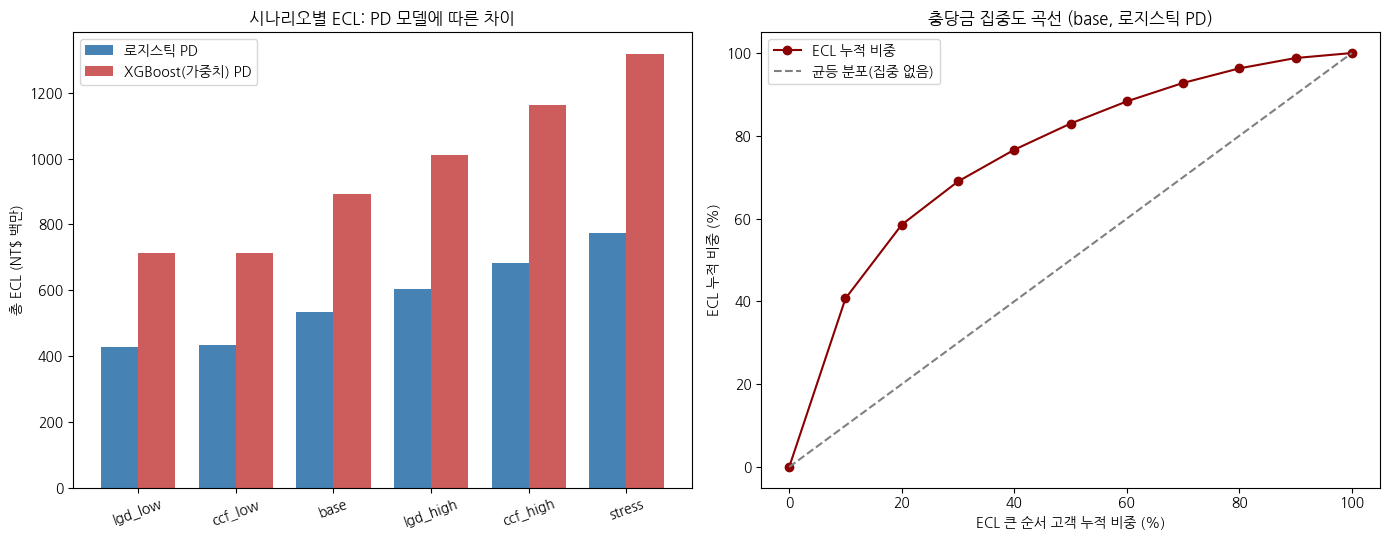

In [6]:
# ============================================================
# [Cell 5] 시나리오 민감도 + Stage 정의 영향 + PD 모델 차이 분해 (SQL)
# ============================================================

# ------------------------------------------------------------
# 1) 시나리오 추가: 코드는 그대로 두고 '파라미터 행'만 추가
# ------------------------------------------------------------
# INSERT OR REPLACE: 같은 이름의 시나리오가 있으면 덮어씀 -> 셀을 다시 실행해도 오류 없음
# 시나리오 이름 규칙: base(기준) / lgd_low·high(LGD만 변경) / ccf_low·high(CCF만 변경) / stress(둘 다 악화)
scenario_sql = """
INSERT OR REPLACE INTO ecl_params VALUES ('base',     0.75, 0.50, 0.15);
INSERT OR REPLACE INTO ecl_params VALUES ('lgd_low',  0.60, 0.50, 0.15);
INSERT OR REPLACE INTO ecl_params VALUES ('lgd_high', 0.85, 0.50, 0.15);
INSERT OR REPLACE INTO ecl_params VALUES ('ccf_low',  0.75, 0.30, 0.15);
INSERT OR REPLACE INTO ecl_params VALUES ('ccf_high', 0.75, 0.80, 0.15);
INSERT OR REPLACE INTO ecl_params VALUES ('stress',   0.85, 0.80, 0.15);
"""
conn.executescript(scenario_sql)

# ------------------------------------------------------------
# 2) 통합 ECL 뷰 (v_ecl_all): Stage 정의(6개월/3개월) x 시나리오 x 고객
# ------------------------------------------------------------
# stage_union: 같은 고객을 두 가지 Stage 정의로 각각 한 번씩 나열 (UNION ALL)
# 이후 계산식은 3단계의 v_ecl과 동일 (Stage 1: 12개월 / Stage 2: 3년 전체기간 / Stage 3: PD 100%)
ecl_all_sql = """
DROP VIEW IF EXISTS v_ecl_all;
CREATE VIEW v_ecl_all AS
WITH stage_union AS (
    SELECT '6개월' AS stage_def, cust_id, stage, drawn_amt, undrawn_amt
    FROM v_customer_stage
    UNION ALL
    SELECT '3개월', s.cust_id, m.stage, s.drawn_amt, s.undrawn_amt
    FROM v_customer_stage s
    JOIN v_stage_monthly m ON s.cust_id = m.cust_id AND m.month_seq = 6
),
base AS (
    SELECT p.scenario, u.stage_def, u.cust_id, u.stage, u.drawn_amt,
           u.drawn_amt + CASE WHEN u.stage = 3 THEN 0.0
                              ELSE p.ccf * u.undrawn_amt END AS ead,
           p.lgd, p.discount_rate AS r, d.pd_logit, d.pd_xgb_weighted
    FROM stage_union u
    CROSS JOIN ecl_params p
    JOIN pd_scores d ON u.cust_id = d.cust_id
)
SELECT scenario, stage_def, cust_id, stage, drawn_amt, ead,
    CASE stage
        WHEN 1 THEN pd_logit * lgd * ead / (1 + r)
        WHEN 2 THEN lgd * ead * pd_logit * (
                        1.0 / (1 + r)
                      + (1 - pd_logit) / ((1 + r) * (1 + r))
                      + (1 - pd_logit) * (1 - pd_logit) / ((1 + r) * (1 + r) * (1 + r)))
        ELSE lgd * ead
    END AS ecl_logit,
    CASE stage
        WHEN 1 THEN pd_xgb_weighted * lgd * ead / (1 + r)
        WHEN 2 THEN lgd * ead * pd_xgb_weighted * (
                        1.0 / (1 + r)
                      + (1 - pd_xgb_weighted) / ((1 + r) * (1 + r))
                      + (1 - pd_xgb_weighted) * (1 - pd_xgb_weighted) / ((1 + r) * (1 + r) * (1 + r)))
        ELSE lgd * ead
    END AS ecl_xgb
FROM base;
"""
conn.executescript(ecl_all_sql)

# ------------------------------------------------------------
# 3) [1] 시나리오별 총 ECL (Stage 정의 = 6개월, 단위: NT$ 백만)
# ------------------------------------------------------------
print("=== [1] 시나리오별 총 ECL 민감도 ===")
res1 = q("""
SELECT
    e.scenario AS 시나리오,
    p.lgd AS LGD,
    p.ccf AS CCF,
    ROUND(SUM(e.ead) / 1000000.0, 1) AS EAD,
    ROUND(SUM(e.ecl_logit) / 1000000.0, 1) AS ECL_로지스틱,
    ROUND(SUM(e.ecl_xgb) / 1000000.0, 1) AS ECL_XGB,
    ROUND(SUM(e.ecl_xgb) * 1.0 / SUM(e.ecl_logit), 3) AS XGB_배수,
    ROUND((SUM(e.ecl_xgb) - SUM(e.ecl_logit)) / 1000000.0, 1) AS 과대적립액,
    ROUND(100.0 * (SUM(e.ecl_logit) / (SELECT SUM(ecl_logit) FROM v_ecl_all
                                       WHERE scenario = 'base' AND stage_def = '6개월') - 1), 1)
        AS base대비_로지스틱_pct
FROM v_ecl_all e
JOIN ecl_params p ON e.scenario = p.scenario
WHERE e.stage_def = '6개월'
GROUP BY e.scenario, p.lgd, p.ccf
ORDER BY SUM(e.ecl_logit)
""")
print(res1)

# ------------------------------------------------------------
# 4) [2] Stage 정의에 따른 ECL 차이 (base 시나리오)
# ------------------------------------------------------------
print("\n=== [2-a] Stage 정의별 Stage 구성과 ECL (base, 단위: NT$ 백만) ===")
print(q("""
SELECT stage_def AS Stage정의, stage AS Stage, COUNT(*) AS 고객수,
       ROUND(SUM(ead) / 1000000.0, 1) AS EAD,
       ROUND(SUM(ecl_logit) / 1000000.0, 1) AS ECL_로지스틱,
       ROUND(SUM(ecl_xgb) / 1000000.0, 1) AS ECL_XGB
FROM v_ecl_all
WHERE scenario = 'base'
GROUP BY stage_def, stage
ORDER BY stage_def, stage
"""))

print("\n=== [2-b] Stage 정의별 총 ECL (base) ===")
print(q("""
SELECT stage_def AS Stage정의,
       ROUND(SUM(ecl_logit) / 1000000.0, 1) AS 총ECL_로지스틱,
       ROUND(SUM(ecl_xgb) / 1000000.0, 1) AS 총ECL_XGB
FROM v_ecl_all
WHERE scenario = 'base'
GROUP BY stage_def
"""))

# ------------------------------------------------------------
# 5) [3] XGBoost 과대적립의 Stage별 분해 (base, Stage 정의 = 6개월)
# ------------------------------------------------------------
print("\n=== [3] 과대적립(XGB - 로지스틱)의 Stage별 분해 ===")
print(q("""
SELECT stage AS Stage,
       ROUND((SUM(ecl_xgb) - SUM(ecl_logit)) / 1000000.0, 1) AS 과대적립액,
       ROUND(100.0 * (SUM(ecl_xgb) - SUM(ecl_logit)) /
             (SELECT SUM(ecl_xgb) - SUM(ecl_logit) FROM v_ecl_all
              WHERE scenario = 'base' AND stage_def = '6개월'), 1) AS 비중_pct
FROM v_ecl_all
WHERE scenario = 'base' AND stage_def = '6개월'
GROUP BY stage
ORDER BY stage
"""))

# ------------------------------------------------------------
# 6) 시각화: (좌) 시나리오별 ECL 비교  (우) 충당금 집중도 곡선
# ------------------------------------------------------------
dec = q("""
WITH ranked AS (
    SELECT ecl_logit, NTILE(10) OVER (ORDER BY ecl_logit DESC) AS decile
    FROM v_ecl_all
    WHERE scenario = 'base' AND stage_def = '6개월'
)
SELECT decile, SUM(ecl_logit) AS ecl FROM ranked GROUP BY decile ORDER BY decile
""")
cum_share = [0] + list(dec['ecl'].cumsum() / dec['ecl'].sum() * 100)   # 누적 ECL 비중(%)
cust_share = [0] + list(range(10, 110, 10))                              # 고객 누적 비중(%)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x = np.arange(len(res1)); w = 0.38
axes[0].bar(x - w/2, res1['ECL_로지스틱'], w, label='로지스틱 PD', color='steelblue')
axes[0].bar(x + w/2, res1['ECL_XGB'], w, label='XGBoost(가중치) PD', color='indianred')
axes[0].set_xticks(x)
axes[0].set_xticklabels(res1['시나리오'], rotation=20)
axes[0].set_ylabel('총 ECL (NT$ 백만)')
axes[0].set_title('시나리오별 ECL: PD 모델에 따른 차이')
axes[0].legend()

axes[1].plot(cust_share, cum_share, marker='o', color='darkred', label='ECL 누적 비중')
axes[1].plot([0, 100], [0, 100], linestyle='--', color='gray', label='균등 분포(집중 없음)')
axes[1].set_xlabel('ECL 큰 순서 고객 누적 비중 (%)')
axes[1].set_ylabel('ECL 누적 비중 (%)')
axes[1].set_title('충당금 집중도 곡선 (base, 로지스틱 PD)')
axes[1].legend()

plt.tight_layout()
plt.show()

PD 캘리브레이션 오류 하나가 LGD·CCF를 동시에 최악으로 잡은 스트레스 시나리오보다 큰 오차를 생성. XGBoost 배수는 시나리오와 무관하게 1.64~1.70배로 안정적이라, LGD·CCF 가정 조정으로는 없앨 수 없는 구조적 오차.
LGD는 ECL과 1:1로 움직이고(탄력성 1.0), CCF는 약 0.47. 미사용 한도는 Stage 1·2의 EAD에만 들어가서 절반 수준으로 반영됨. 다만 CCF 가정 범위(30~80%)가 넓어서 절대 영향은 큼.
Stage 2 정의를 바꾸면 고객 구성은 17% 달라지지만 ECL은 4%만 변함. 이동한 1,629명의 EAD가 전체의 4.2%뿐이기 때문.

=== [1] PD 품질 비교 (실제 부실률 22.12%) ===
                  모델  평균PD(%)  실제대비배수    AUC  Brier  LogLoss  ECE(%p)
                로지스틱  22.1266  1.0003 0.7544 0.1388   0.4447   0.7725
         XGBoost(원본)  42.0563  1.9013 0.7756 0.1799   0.5454  19.9363
XGBoost(Isotonic 보정)  22.1179  0.9999 0.7735 0.1354   0.4321   0.3818

=== [2] Stage별 ECL: PD 종류별 비교 (base, 단위: NT$ 백만) ===
   Stage      EAD  ECL_로지스틱  ECL_XGB_원본  ECL_XGB_보정
0      1 2,431.60    172.90      411.90      168.00
1      2   830.10    343.00      462.60      340.50
2      3    24.00     18.00       18.00       18.00

=== [3] 포트폴리오 전체 ECL ===
로지스틱         : 533.9
XGBoost(원본)    : 892.5  (로지스틱 대비 1.672배, 과대적립 358.6)
XGBoost(보정)    : 526.5  (로지스틱 대비 0.986배, 차이 -7.4)


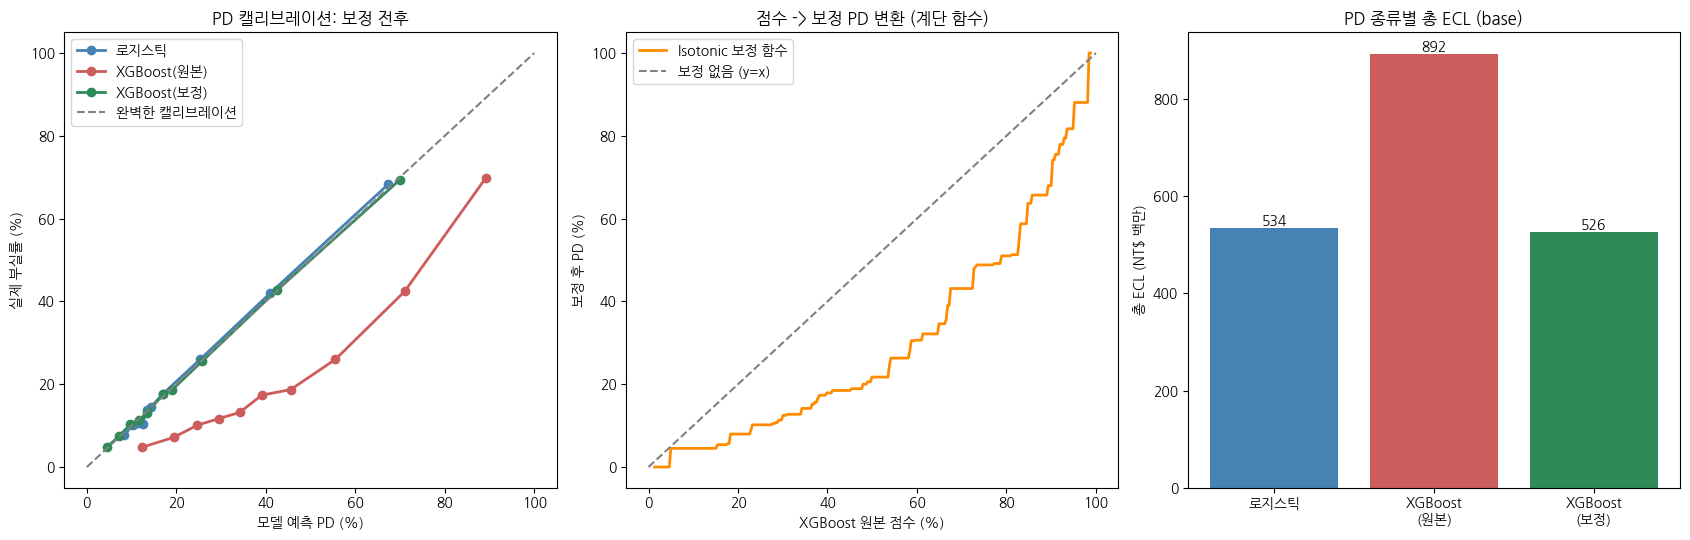

In [7]:
# ============================================================
# [Cell 6 - 보너스] XGBoost PD 확률 보정(Isotonic) + ECL 과대적립 재계산
# ============================================================
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

assert 'pd_xgb_weighted' in df.columns, "1단계 셀을 먼저 실행해주세요."

# ------------------------------------------------------------
# 1) Isotonic 보정: 교차적합(cross-fitting)으로 공정하게 보정 PD 생성
# ------------------------------------------------------------
# raw_score : 1단계에서 이미 out-of-fold로 만든 XGBoost 원본 점수 (고객 본인은 학습에 쓰이지 않음)
# 보정 함수를 4개 조각으로 학습하고 나머지 1개 조각에 적용 -> 모든 고객이 '자기를 제외한' 보정 함수를 받음
# y_min/y_max: 확률이므로 0~1 범위 유지 / out_of_bounds='clip': 학습 범위 밖 점수는 끝값으로 처리
raw_score = df['pd_xgb_weighted'].values
y_arr = df['default'].values
iso_oof = np.zeros(len(df))

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
for tr_idx, te_idx in skf2.split(raw_score, y_arr):
    iso = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip')
    iso.fit(raw_score[tr_idx], y_arr[tr_idx])          # 점수 -> 실제 부실 여부 관계 학습
    iso_oof[te_idx] = iso.predict(raw_score[te_idx])   # 학습에 안 쓴 고객에게 적용

df['pd_xgb_iso'] = iso_oof

# ------------------------------------------------------------
# 2) 보정 PD를 SQL 테이블(pd_scores)에 새 컬럼으로 추가
# ------------------------------------------------------------
# 임시 테이블에 PRIMARY KEY를 먼저 만들어 두면 UPDATE 때 고객별 조회가 빨라짐
conn.executescript("""
DROP TABLE IF EXISTS tmp_iso;
CREATE TABLE tmp_iso (cust_id INTEGER PRIMARY KEY, pd_xgb_iso REAL);
""")
pd.DataFrame({'cust_id': df['ID'], 'pd_xgb_iso': df['pd_xgb_iso']}).to_sql(
    'tmp_iso', conn, if_exists='append', index=False)

# 셀을 다시 실행해도 오류가 나지 않도록 컬럼이 이미 있는지 확인 후 추가
cols = [r[1] for r in conn.execute("PRAGMA table_info(pd_scores)")]
if 'pd_xgb_iso' not in cols:
    conn.execute("ALTER TABLE pd_scores ADD COLUMN pd_xgb_iso REAL")
conn.execute("""
UPDATE pd_scores
SET pd_xgb_iso = (SELECT t.pd_xgb_iso FROM tmp_iso t WHERE t.cust_id = pd_scores.cust_id)
""")
conn.commit()

# 성능 개선: 뷰(조회할 때마다 재계산)를 물리 테이블로 한 번만 만들어 둠 (5단계에서 느렸던 부분)
conn.executescript("""
DROP TABLE IF EXISTS stage_base;
CREATE TABLE stage_base AS SELECT * FROM v_customer_stage;
CREATE INDEX idx_stage_base ON stage_base(cust_id);
""")

# ------------------------------------------------------------
# 3) 세 가지 PD의 품질 비교 (평균PD, 변별력, 확률 정확도)
# ------------------------------------------------------------
# AUC   : 순위 변별력 (보정 후에도 거의 유지돼야 함)
# Brier : 예측확률과 실제 결과의 평균 제곱오차 (낮을수록 좋음)
# ECE   : 10분위별 |예측PD - 실제부실률|의 평균 (0에 가까울수록 확률을 믿을 수 있음)
def decile_table(col):
    tmp = pd.DataFrame({'p': df[col], 'y': df['default']})
    # rank(method='first'): 동점이 많은 보정 점수도 10등분 가능하게 순번으로 변환
    tmp['decile'] = pd.qcut(tmp['p'].rank(method='first'), 10, labels=False) + 1
    return tmp.groupby('decile').agg(예측PD=('p', 'mean'), 실제부실률=('y', 'mean'))

models = {'로지스틱': 'pd_logit',
          'XGBoost(원본)': 'pd_xgb_weighted',
          'XGBoost(Isotonic 보정)': 'pd_xgb_iso'}
rows = []
for name, col in models.items():
    p = df[col].clip(1e-6, 1 - 1e-6)
    dt = decile_table(col)
    rows.append({'모델': name,
                 '평균PD(%)': p.mean() * 100,
                 '실제대비배수': p.mean() / df['default'].mean(),
                 'AUC': roc_auc_score(df['default'], p),
                 'Brier': brier_score_loss(df['default'], p),
                 'LogLoss': log_loss(df['default'], p),
                 'ECE(%p)': (dt['예측PD'] - dt['실제부실률']).abs().mean() * 100})
metrics = pd.DataFrame(rows)
print("=== [1] PD 품질 비교 (실제 부실률 22.12%) ===")
print(metrics.to_string(index=False, float_format=lambda v: f'{v:.4f}'))

# ------------------------------------------------------------
# 4) SQL로 ECL 재계산: 세 가지 PD를 한 번의 쿼리로 (base 시나리오)
# ------------------------------------------------------------
# ecl_case(): PD 컬럼 이름만 바꿔 같은 ECL 공식(5단계와 동일)을 만들어 주는 도우미
def ecl_case(pdc):
    ead = "(s.drawn_amt + p.ccf * s.undrawn_amt)"
    return f"""CASE s.stage
        WHEN 1 THEN {pdc} * p.lgd * {ead} / (1 + p.discount_rate)
        WHEN 2 THEN p.lgd * {ead} * {pdc} * (
              1.0 / (1 + p.discount_rate)
            + (1 - {pdc}) / ((1 + p.discount_rate) * (1 + p.discount_rate))
            + (1 - {pdc}) * (1 - {pdc}) / ((1 + p.discount_rate) * (1 + p.discount_rate) * (1 + p.discount_rate)))
        ELSE p.lgd * s.drawn_amt
    END"""

stage_df = q(f"""
SELECT s.stage AS Stage,
       ROUND(SUM(s.drawn_amt + CASE WHEN s.stage = 3 THEN 0 ELSE p.ccf * s.undrawn_amt END) / 1000000.0, 1) AS EAD,
       ROUND(SUM({ecl_case('d.pd_logit')}) / 1000000.0, 1)          AS ECL_로지스틱,
       ROUND(SUM({ecl_case('d.pd_xgb_weighted')}) / 1000000.0, 1)   AS ECL_XGB_원본,
       ROUND(SUM({ecl_case('d.pd_xgb_iso')}) / 1000000.0, 1)        AS ECL_XGB_보정
FROM stage_base s
JOIN pd_scores d ON s.cust_id = d.cust_id
JOIN ecl_params p ON p.scenario = 'base'
GROUP BY s.stage
ORDER BY s.stage
""")
print("\n=== [2] Stage별 ECL: PD 종류별 비교 (base, 단위: NT$ 백만) ===")
print(stage_df)

tot = stage_df[['ECL_로지스틱', 'ECL_XGB_원본', 'ECL_XGB_보정']].sum()
print("\n=== [3] 포트폴리오 전체 ECL ===")
print(f"로지스틱         : {tot['ECL_로지스틱']:,.1f}")
print(f"XGBoost(원본)    : {tot['ECL_XGB_원본']:,.1f}  (로지스틱 대비 {tot['ECL_XGB_원본']/tot['ECL_로지스틱']:.3f}배, 과대적립 {tot['ECL_XGB_원본']-tot['ECL_로지스틱']:,.1f})")
print(f"XGBoost(보정)    : {tot['ECL_XGB_보정']:,.1f}  (로지스틱 대비 {tot['ECL_XGB_보정']/tot['ECL_로지스틱']:.3f}배, 차이 {tot['ECL_XGB_보정']-tot['ECL_로지스틱']:,.1f})")

# ------------------------------------------------------------
# 5) 시각화: (좌) 캘리브레이션  (중) 보정 함수  (우) 총 ECL 비교
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

for name, col, color in [('로지스틱', 'pd_logit', 'steelblue'),
                         ('XGBoost(원본)', 'pd_xgb_weighted', 'indianred'),
                         ('XGBoost(보정)', 'pd_xgb_iso', 'seagreen')]:
    dt = decile_table(col)
    axes[0].plot(dt['예측PD'] * 100, dt['실제부실률'] * 100, marker='o', lw=2, label=name, color=color)
axes[0].plot([0, 100], [0, 100], linestyle='--', color='gray', label='완벽한 캘리브레이션')
axes[0].set_xlabel('모델 예측 PD (%)'); axes[0].set_ylabel('실제 부실률 (%)')
axes[0].set_title('PD 캘리브레이션: 보정 전후'); axes[0].legend()

iso_full = IsotonicRegression(y_min=0, y_max=1, out_of_bounds='clip').fit(raw_score, y_arr)
grid = np.linspace(raw_score.min(), raw_score.max(), 300)
axes[1].plot(grid * 100, iso_full.predict(grid) * 100, color='darkorange', lw=2, label='Isotonic 보정 함수')
axes[1].plot([0, 100], [0, 100], linestyle='--', color='gray', label='보정 없음 (y=x)')
axes[1].set_xlabel('XGBoost 원본 점수 (%)'); axes[1].set_ylabel('보정 후 PD (%)')
axes[1].set_title('점수 -> 보정 PD 변환 (계단 함수)'); axes[1].legend()

labels = ['로지스틱', 'XGBoost\n(원본)', 'XGBoost\n(보정)']
vals = [tot['ECL_로지스틱'], tot['ECL_XGB_원본'], tot['ECL_XGB_보정']]
bars = axes[2].bar(labels, vals, color=['steelblue', 'indianred', 'seagreen'])
for b, v in zip(bars, vals):
    axes[2].text(b.get_x() + b.get_width() / 2, v, f'{v:,.0f}', ha='center', va='bottom')
axes[2].set_ylabel('총 ECL (NT$ 백만)'); axes[2].set_title('PD 종류별 총 ECL (base)')

plt.tight_layout()
plt.show()

순위는 유지하고 확률만 수정. AUC는 0.7756에서 0.7735로 0.002만 내려갔고, ECE는 19.94에서 0.38로 줄어들게 됨. 캘리브레이션 그래프에서도 초록 선이 로지스틱 선과 거의 겹침.
과대적립이 사라짐. ECL이 892.5에서 526.5로 내려와 로지스틱 대비 358.6 과대적립이 -7.4(-1.4%)가 됨. 약 98%가 해소됨. Stage 1은 411.9에서 168.0, Stage 2는 462.6에서 340.5로 내려옴. 3단계 [C]의 892.4와 0.1 차이는 Stage별 반올림 값을 합산해서 생기게 된 것.
보정된 XGBoost가 모든 지표에서 로지스틱을 앞서게 됨. AUC가 더 높고 Brier, LogLoss, ECE도 더 낮음. 다만 Brier 차이(0.1354 vs 0.1388)는 작음.
